# 🚀 **Demystifying AI: Breast Cancer Detection with Code!** 🚀

# Welcome to this workshop!

**Objective:** Explore how artificial intelligence can help detect breast cancer from medical images. \
**Prerequisites:** None! Just curiosity and a desire to learn. 😊 \
**Tool:** Google Colab (no need to install anything!)

## Step 1: Installation and Data Loading

We will use a dataset that contains mammograms.
To simplify, we will work with images already converted to JPEG format (easier to handle).

In [ ]:
# Import necessary libraries
import kagglehub  # To easily download datasets from Kaggle
import os  # To interact with the file system (finding image paths, etc.)

import matplotlib.pyplot as plt  # To display images and graphs
import matplotlib.image as mpimg  # To read images

import cv2  # OpenCV: a very powerful library for image processing
import numpy as np  # To manipulate arrays of numbers (images are arrays of pixels)

import tensorflow as tf  # TensorFlow: Google's library for deep learning
from tensorflow.keras.models import Sequential  # To create a sequential model (stacked layers)
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # The different layers of our network

import pandas as pd  # To manipulate structured data (tables)
from sklearn.model_selection import train_test_split  # To split the dataset into training and validation


In [ ]:
# Get dataset from Kaggle
# https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset

path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1


In [ ]:
# Get the path containing the image folder
img_dir = ''
for files in os.listdir(path):
  files_dir = os.path.join(path, files)
  img_dir = os.path.join(path, files_dir)
  print("Path : ", img_dir)

Path :  /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT


## Exploration and Display of Images

In [ ]:
# Function to retrieve all file paths
def get_all_files_path(root_dir: str) -> list:
    """
    Recursively retrieves the paths of all files in a directory.

    Args:
        root_dir: The root directory to explore.

    Returns:
        A list containing the absolute paths of all files (except those containing "_mask").
    """
    all_files = []
    for root, _, files in os.walk(root_dir):  # Recursive traversal of the directory tree
        for file in files:
            if "_mask" not in file:  # We do not want to keep the transformed images (masks)
                all_files.append(os.path.join(root, file))  # Absolute path of the file
    return all_files

In [ ]:
# List of all *training image* files (we focus on training for now)
train_files = get_all_files_path(img_dir)
print(f"Total number of training images: {len(train_files)}")

Nombre total d'images d'entraînement: 780


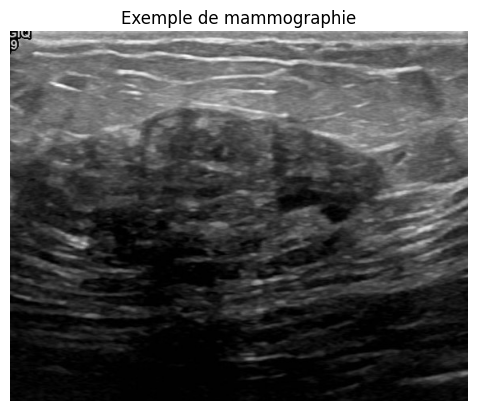

Chemin de l'image : /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT/malignant/malignant (68).png


In [ ]:
# Display a random image
sample_image_path = train_files[0]   # Path to a training image
img = mpimg.imread(sample_image_path) # Read the image with matplotlib
plt.imshow(img, cmap='gray')  # Display the image in grayscale
plt.title("Example of Mammogram")
plt.axis('off')  # Hide the axes
plt.show()
print("Image path:", sample_image_path)

## Step 2: Image Preprocessing and Cleaning

Image preprocessing is crucial in deep learning for several reasons:

Standardization: Neural networks perform better with standardized input data. This means:

Uniform size: All images must have the same size (height, width) to be processed in batches. Therefore, we resize them to 224x224 pixels.
Consistent value range: Pixel values should be within a known and limited range. Normalization (division by 255.0) scales the values between 0 and 1.
Quality improvement:

Contrast: Breast cancer can be difficult to distinguish from healthy tissue on a mammogram. Contrast enhancement (with CLAHE) helps highlight important details.
Noise reduction: Although the code does not explicitly include noise reduction, it is a common preprocessing step that can improve performance.
Model compatibility:

Data format: TensorFlow expects images with an explicit channel dimension (even for grayscale images). np.expand_dims adds this dimension.
In summary, preprocessing transforms raw images into an optimal format for learning by the neural network, improving the model's accuracy and robustness. Without preprocessing, the model might struggle to learn or not converge at all.

In [ ]:
def preprocess_image(image_path):
    """
    Preprocesses an image:
        1. Reads the image in grayscale.
        2. Resizes it to a standard size (224x224 pixels).
        3. Enhances the contrast using CLAHE.
        4. Normalizes pixel values between 0 and 1.
        5. Adds a channel dimension (necessary for TensorFlow).

    Args:
        image_path: The path to the image to preprocess.

    Returns:
        The preprocessed image as a NumPy array.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale
    img = cv2.resize(img, (224, 224))  # Resize to a standard size (224x224)

    # Enhance contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    img = img / 255.0  # Normalize pixels: values between 0 and 1
    img = np.expand_dims(img, axis=-1)  # Add a channel dimension (for TensorFlow)
    return img

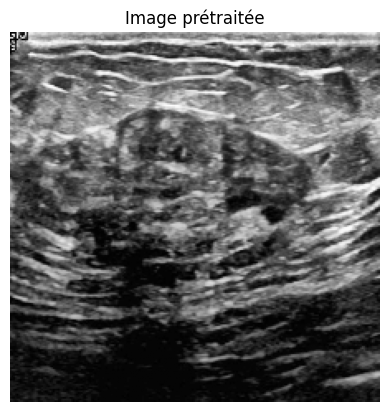

In [ ]:
# Example with the previous image
processed_img = preprocess_image(sample_image_path)
plt.imshow(processed_img, cmap='gray')  # Display the image in grayscale.
plt.title("Preprocessed Image")
plt.axis('off')
plt.show()

## Step 3: Creating the CNN Model

In [ ]:
def create_cnn_model():
    """
    Creates a simple CNN (Convolutional Neural Network) model for binary classification.

    The model consists of:
        - Convolutional layers (Conv2D) to extract features from images.
        - Pooling layers (MaxPooling2D) to reduce the dimensionality of the data and computation time.
        - A flattening layer (Flatten) to convert 2D data into a 1D vector.
        - Dense layers (Dense) for classification.
        - A Dropout layer for regularization (to avoid overfitting).

    Returns:
        An uncompiled Keras model.
    """
    model = Sequential([
        # First convolutional layer: 32 filters of size 3x3, ReLU activation function
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
        MaxPooling2D((2, 2)),  # Reduces the image size by 2

        # Second convolutional layer: 64 filters of size 3x3, ReLU activation
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Third convolutional layer: 128 filters of size 3x3, ReLU activation
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),  # Flattens the data into a 1D vector

        # Dense (fully connected) layer: 128 neurons, ReLU activation
        Dense(128, activation='relu'),
        Dropout(0.5),  # Dropout for regularization (50% of neurons randomly deactivated)

        # Output layer: 1 neuron (binary classification), sigmoid activation
        Dense(1, activation='sigmoid')  # Sigmoid to get a probability between 0 and 1
    ])
    return model

In [ ]:
# Creation and compilation of the model
model = create_cnn_model()

# Compilation of the model
model.compile(optimizer='adam',  # Adam optimizer: gradient descent algorithm
              loss='binary_crossentropy',  # Loss function for binary classification
              metrics=['accuracy'])  # Evaluation metric: accuracy

# Display the model summary
model.summary()

model.build(input_shape=(None, 224, 224, 1))  # None for the batch size

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

# Explanation of Concepts:
   - CNN (Convolutional Neural Network): A type of deep neural network particularly suited for image processing. It uses convolutional layers to automatically extract relevant features (edges, textures, etc.).
   - Convolutional Layer (Conv2D): Applies filters (small matrices) to the image to detect patterns. Each filter produces an "activation map" indicating where the pattern is present.
   - Pooling Layer (MaxPooling2D): Reduces the size of the activation maps by keeping only the maximum value in a small window (often 2x2). This reduces noise and computation time.
   - Activation Function (ReLU, sigmoid): Introduces non-linearity into the network, allowing it to learn complex relationships. ReLU (Rectified Linear Unit) is often used in hidden layers, while the sigmoid is common for binary classification output (probability between 0 and 1).
   - Dropout: A regularization technique that randomly "turns off" certain neurons during training. This forces the network to learn more robust representations and prevents overfitting.
   - Optimizer (Adam): An algorithm that adjusts the network's weights during training to minimize the loss function. Adam is a popular variant of gradient descent.
   - Loss Function (binary_crossentropy): Measures the error between the model's predictions and the true values. Binary cross-entropy is suitable for binary classification.


## Step 3 : Creation of the dataset

In [ ]:
# Creation of the TensorFlow dataset
def create_dataset(dataframe):
    """
    Creates a TensorFlow dataset from a pandas DataFrame.

    Args:
        dataframe: The DataFrame containing the image paths and labels.

    Returns:
        A TensorFlow dataset ready for training or validation.
    """
    # Create a dataset from the image paths and labels
    ds = tf.data.Dataset.from_tensor_slices((dataframe['filename'].values, dataframe['label'].values))

    def load_and_preprocess(image_path, label):
        """Loads and preprocesses an image from its path."""
        img = tf.io.read_file(image_path)  # Read the image file
        img = tf.image.decode_jpeg(img, channels=1)  # Decode the JPEG image (grayscale)
        img = tf.image.resize(img, [224, 224])  # Resize to 224x224
        img = tf.cast(img, tf.float32) / 255.0  # Normalize the pixels (float32)
        return img, label

    # Apply the loading and preprocessing function to each element of the dataset
    ds = ds.map(load_and_preprocess)
    # Create batches of size 32 (group 32 images)
    ds = ds.batch(32)
    # Prepare the next batches in the background (optimization)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


In [ ]:
# Create the dataframe with the image path and its label
labels = [1 if "malignant" in f else 0 for f in train_files]  # 1 if malignant, 0 otherwise
df = pd.DataFrame({"filename": train_files, "label": labels})

# Split the data into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)  # 80% train, 20% validation

# Create the training and validation datasets
train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)


## Step 4: Model Training

In [ ]:
history = model.fit(
    train_ds,  # The training dataset
    epochs=5,  # Number of epochs (complete passes over the dataset)
    validation_data=val_ds  # The validation dataset
)

# Explanation:
#   - Epoch: A complete pass over the entire training dataset. During an epoch,
#     the model sees all the training images, adjusts its weights, and calculates the loss
#     (error) and metrics (such as accuracy). The more epochs, the more opportunities the model
#     has to learn, but be careful of overfitting!


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.6258 - loss: 0.8675 - val_accuracy: 0.7628 - val_loss: 0.5265
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7042 - loss: 0.5803 - val_accuracy: 0.7628 - val_loss: 0.5242
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.7042 - loss: 0.5085 - val_accuracy: 0.7628 - val_loss: 0.4915
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7168 - loss: 0.4661 - val_accuracy: 0.8141 - val_loss: 0.4521
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7599 - loss: 0.4124 - val_accuracy: 0.7949 - val_loss: 0.4595


## Step 5: Model Evaluation

In [ ]:
loss, accuracy = model.evaluate(val_ds)  # Evaluate the model on the validation dataset
print(f"Loss on the validation set: {loss:.4f}")
print(f"Accuracy on the validation set: {accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 670ms/step - accuracy: 0.7880 - loss: 0.4300
Perte (loss) sur l'ensemble de validation : 0.4595
Précision (accuracy) sur l'ensemble de validation : 0.7949


# Exercises

### 1. Apply different transformations to the images
### 2. Visualize the model layers and understand their role
### 3. Display images with their predictions and confidence levels of the model
### 4. Check if the model tends to make more errors on certain types of images
### 5. Find examples where the model made mistakes and try to explain why


Documentation / Help:     
https://www.tensorflow.org/api_docs/python/tf/image

- ```tf.random.uniform(()) > 0.5```: A way to randomly decide whether to apply the transformation or not (heads or tails).
- ```tf.image.rot90()```: Rotation by multiples of 90 degrees. k is the number of 90-degree rotations.
- ```tf.image.random_flip_left_right()```: Horizontal flip.
- ```tf.image.random_flip_up_down()```: Vertical flip.
- ```tf.image.random_brightness()```: Random change in brightness. max_delta controls the amplitude of the change.
- ```tf.image.random_contrast()```: Adding a function for contrast variation here would be relevant, and students could do it.


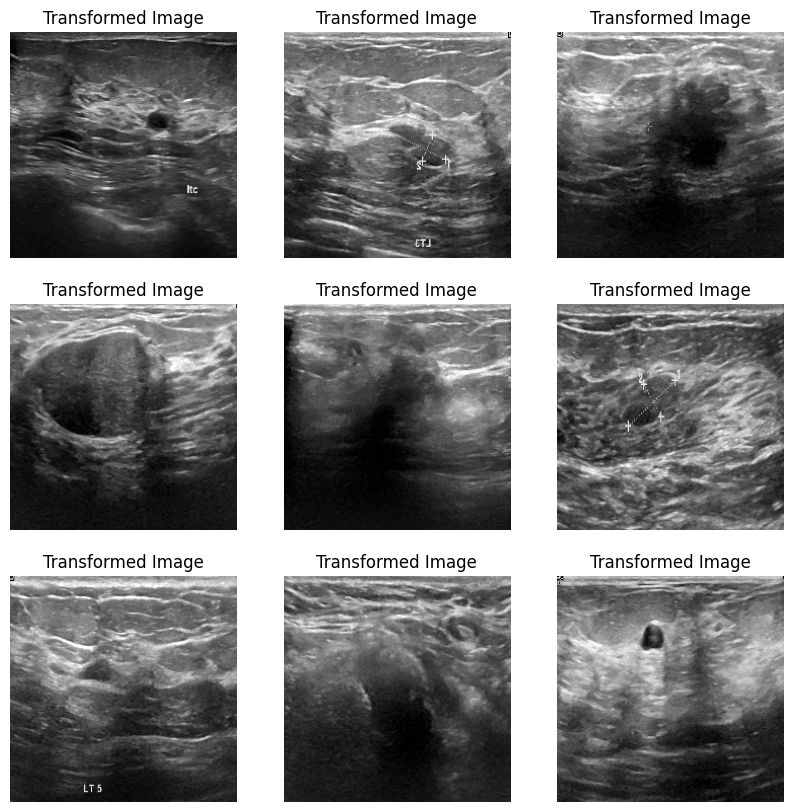

In [ ]:
# ### 1. Apply different transformations to the images

# **What?** Image transformations (or data augmentation) are random modifications
# applied to images during training.
# **Why?** This allows to artificially increase the size of the dataset and make the
# model more robust to variations (rotation, zoom, brightness, etc.).
# **How?** We can use `tf.image` functions or libraries like Keras' `ImageDataGenerator`.
print("\nExercise 1: Apply different transformations to the images")
def apply_random_transformations(image, label):
  """Applies random transformations to an image."""

  # Random rotation
  if tf.random.uniform(()) > 0.5:
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

  # Random horizontal flip
  if tf.random.uniform(()) > 0.5:
    image = tf.image.random_flip_left_right(image)

  # Random zoom
  if tf.random.uniform(()) > 0.5:
    zoom = tf.random.uniform(shape=[2], minval=0.8, maxval=1.2)  # Zoom between 0.8x and 1.2x
    new_size = [int(224 * zoom[0]), int(224 * zoom[1])]
    image = tf.image.resize(image, new_size)
    image = tf.image.resize_with_crop_or_pad(image, 224, 224)  # Crop or pad to 224x224

  # Random brightness adjustment
  if tf.random.uniform(()) > 0.5:
    image = tf.image.random_brightness(image, max_delta=0.2)  # Brightness variation

  # --- ADD YOUR CODE HERE ---
  # 1. Add a vertical flip
  # 2. Add a contrast adjustment
  # 3. Add a translation (tf.roll)
  # 4. Experiment with the parameters of all transformations!

  return image, label

# Apply the random transformations function to the training dataset images.
# Do *not* apply transformations to the validation dataset.
transformed_train_ds = train_ds.map(apply_random_transformations)

# Visualize some transformed images
plt.figure(figsize=(10, 10))
for images, labels in transformed_train_ds.take(1):  # Take a batch of images
  for i in range(9):  # Display 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy(), cmap="gray")
    plt.title("Transformed Image")
    plt.axis("off")
plt.show()



Exercice 2 : Visualiser les couches du modèle
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Forme des activations de la première couche : (1, 109, 109, 64)


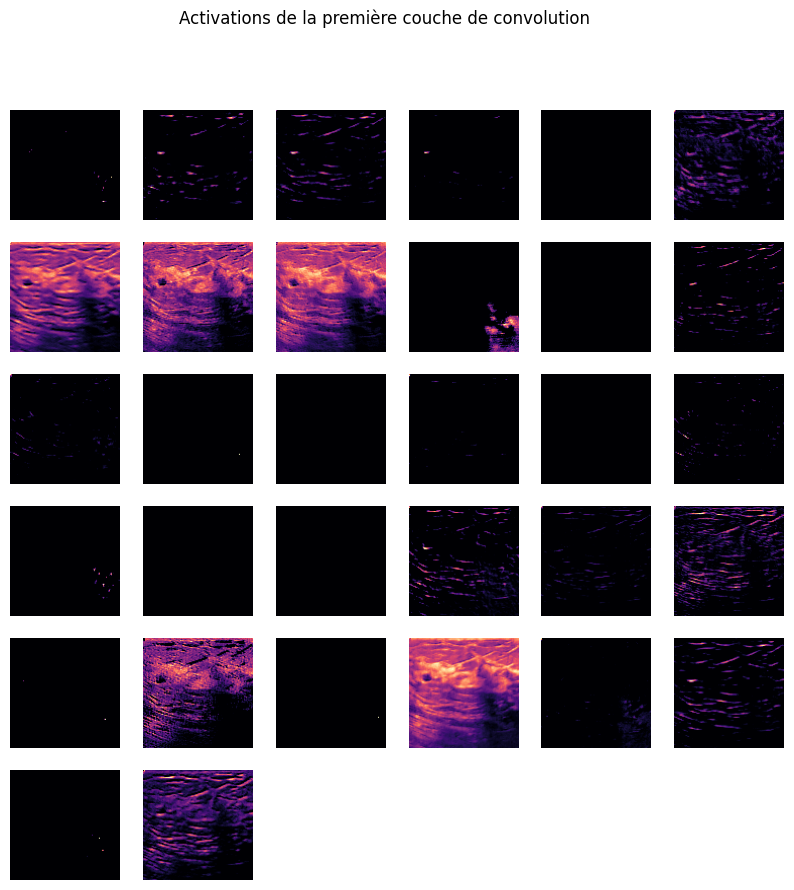

Forme des activations de la première couche de pooling: (1, 111, 111, 32)


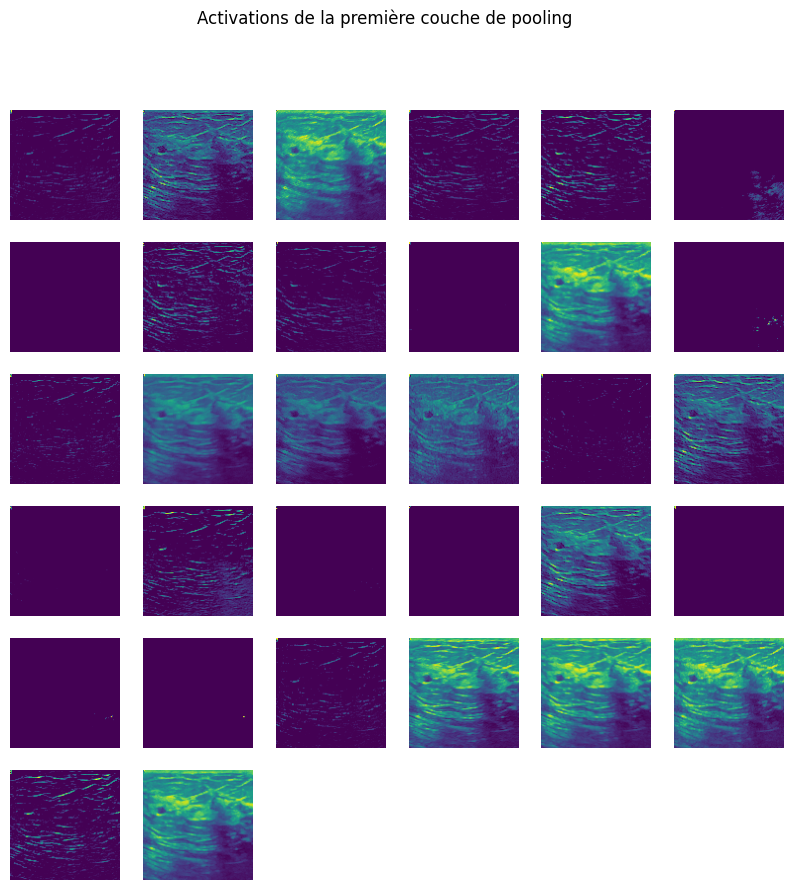

In [ ]:
# ### 2. Visualize the model layers and understand their role

# **What?** Visualize the activations of the intermediate layers of the CNN (convolution, pooling).
# **Why?** Understand what features the model learns to detect at each stage.
# **How?** Create an intermediate model that takes the original input and returns the outputs of the desired layers.
print("\nExercise 2: Visualize the model layers")

# Take an image from the validation dataset (no augmentation here)
sample_image, _ = next(iter(val_ds))
sample_image = sample_image[0:1]  # Keep only one image

# Create a model that will take the original input and return the outputs of *all* layers.
layer_outputs = [layer.output for layer in model.layers]  # List of outputs of each layer
activation_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

# Pass the image through this model to get the activations.
activations = activation_model.predict(sample_image)

# Display the activations of the first convolutional layer.
first_layer_activation = activations[2]
print(f"Shape of the first layer activations: {first_layer_activation.shape}")  # (1, 222, 222, 32)

# Display the 32 activation maps of this layer.
plt.figure(figsize=(10, 10))
for i in range(32):
    ax = plt.subplot(6, 6, i + 1)  # Use a 6x6 grid (for 32 maps + some spaces)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')  # 'viridis' is a nice colormap
    plt.axis('off')
plt.suptitle("Activations of the first convolutional layer")  # General title
plt.show()

# Visualization of the activations of a pooling layer (e.g., the first one)
pooling_layer_activation = activations[1]  # The first pooling layer is at index 1
print(f"Shape of the first pooling layer activations: {pooling_layer_activation.shape}")

plt.figure(figsize=(10, 10))
for i in range(32):  # Display the 32 channels (if the layer has 32 filters, otherwise adjust)
    ax = plt.subplot(6, 6, i + 1)
    plt.imshow(pooling_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Activations of the first pooling layer")
plt.show()

# You can do the same for other layers (second convolution, pooling, etc.).
# Just change the index in `activations[index]`.

# Interpretation:
#   - The first convolutional layers detect low-level features (edges, corners, simple textures).
#   - The following layers combine these features to detect more complex patterns.
#   - The pooling layers reduce the spatial resolution, making the model more invariant to small translations.


## Exercises:

### 1. Visualize other layers

- Modify the index in activations[index] to display the activations of other convolution and pooling layers.
- Observe how the size of the activations changes.
- Try to identify patterns in the activations.

### 2. Change the input image:

- Replace sample_image with other images from the validation dataset.
- Observe how the activations change.
- Try to find images that produce particularly strong or weak activations in certain layers.

### 3. Experiment with colormaps:

- Change cmap='viridis' to other arguments (gray, magma, etc.)

### 4. Add a function to display the layer and the original image side by side (Optional)


Exercice 3 : Afficher des images avec leurs prédictions


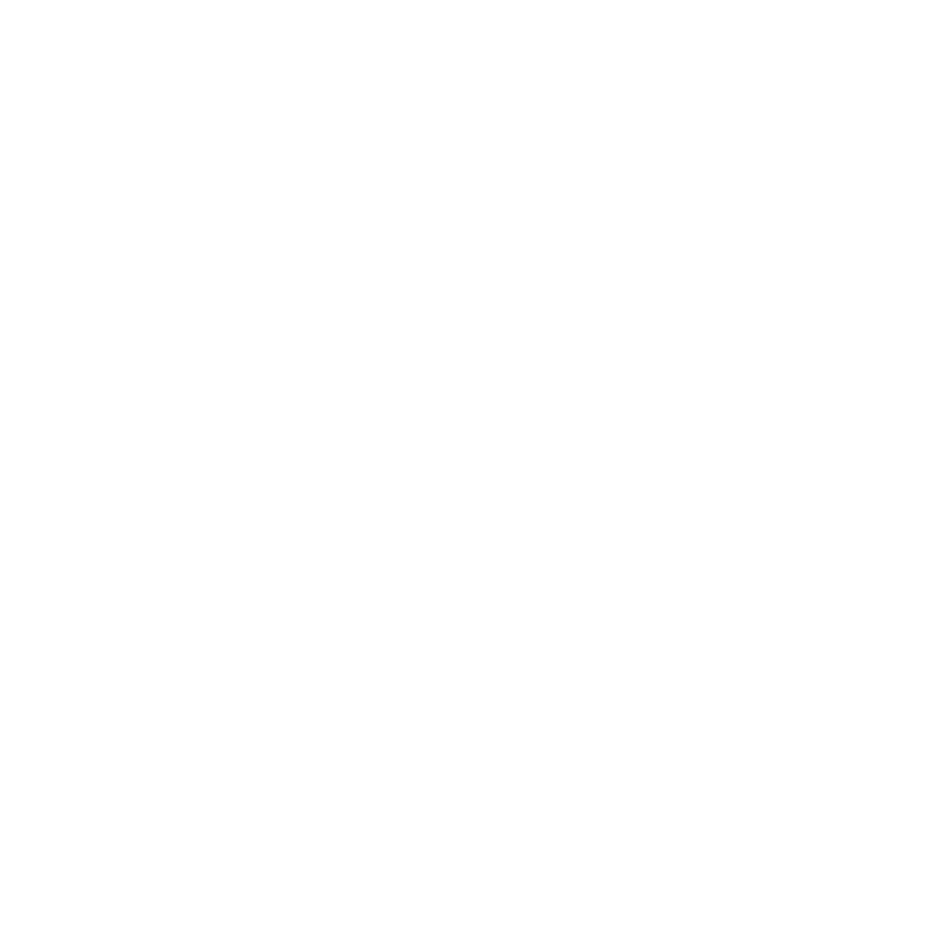

In [ ]:
### 3. Display images with their predictions and confidence levels of the model

# **What?** Visualize the images and display the model's prediction (benign/malignant) along with its confidence level.
# **Why?** Get a visual overview of the model's performance and identify cases where it is very confident or uncertain.
# **How?** Use `model.predict()` to get the predictions, then display them with matplotlib.
print("\nExercise 3: Display images with their predictions")
plt.figure(figsize=(12, 12))  # Enlarge the figure to display more images
# val_ds: We use the validation dataset (important: we do not evaluate on the training data)
for images, labels in val_ds.take(1):  # Take a batch of validation images
#     predictions = # TODO: Get the predictions for this batch - predictions will contain a probability array (one per image in the batch)
#     for i in range(16):  # Display 16 images
#         ax = plt.subplot(4, 4, i + 1) # 4x4 grid
#         plt.imshow(images[i].numpy(), cmap='gray') # Display the image in grayscale

#         predicted_label = # TODO: Malignant if the prediction is greater than 0.5, Benign otherwise
#         true_label = # TODO: same principle with the true label of the image for comparison

#         confidence = predictions[i][0] if predicted_label == "Malignant" else 1 - predictions[i][0]
#         confidence_percent = # TODO: If the prediction is "Malignant", the confidence is directly the predicted probability.
#         # If the prediction is "Benign", the confidence is 1 - probability, because the probability is for being "Malignant".

#         # --- TO GO FURTHER - ADD YOUR CODE HERE ---
#         # 1. Change the classification threshold: What happens if we increase the threshold? If we decrease it?
#         # 2. Display images only if the model is less confident
#         # 3. Sort images by confidence level
#         # 4. Change the colormap
#         # 5. Change the take to visualize other batches

#         title_color = # TODO: Color code to quickly visualize the results - Green if correct, red otherwise
#         plt.title(f"Prediction: {predicted_label}\nTrue: {true_label}\nConfidence: {confidence_percent:.2f}%", color=title_color)
        plt.axis('off')
plt.show()

In [ ]:
# ### 4. Check if the model tends to make more errors on certain types of images

# **What?** Analyze the model's errors based on image characteristics (blurry, contrast, etc.).
# **Why?** Identify the weaknesses of the model and guide improvement efforts (data collection, preprocessing, architecture).
# **How?**
#     1.  Calculate metrics (blur, contrast) on the images.
#     2.  Group the images based on these metrics.
#     3.  Compare the model's error rate in each group.

print("\nExercise 4: Error analysis based on image characteristics")

def calculate_blur(image):
  """Calculate a measure of image blur (variance of the Laplacian)."""
  # Ensure the image is in grayscale and uint8
  if image.dtype != np.uint8:
    image = (image * 255).astype(np.uint8)
  if len(image.shape) > 2 and image.shape[-1] == 1:
    image = image.squeeze(-1)

  # The Laplacian is an operator that detects edges.
  # If the image is sharp, the edges are well-defined, and the variance of the Laplacian is high.
  # If the image is blurry, the edges are diffuse, and the variance is low.
  return cv2.Laplacian(image, cv2.CV_64F).var()


def calculate_contrast(image):
  """Calculate the contrast of an image (standard deviation of intensities)."""
  # The standard deviation measures the dispersion of pixel values around the mean. A high standard deviation means high contrast.
  return np.std(image)

# Lists to store the results
blur_values = []
contrast_values = []
predictions_list = []
true_labels_list = []

# Iterate over the validation set
for images, labels in val_ds:
  predictions = model.predict(images)
  for i in range(images.shape[0]):  # For each image in the batch
    blur = calculate_blur(images[i].numpy()) # Calculate the blur
    contrast = calculate_contrast(images[i].numpy()) # Calculate the contrast

    blur_values.append(blur)
    contrast_values.append(contrast)
    predictions_list.append(predictions[i][0])
    true_labels_list.append(labels[i].numpy())
# Convert to NumPy arrays for easier calculations
blur_values = np.array(blur_values)
contrast_values = np.array(contrast_values)
predictions_list = np.array(predictions_list)
true_labels_list = np.array(true_labels_list)

# --- MODIFY THE CODE BELOW ---

# 1. Change the thresholds for blur and contrast
# Define thresholds for blur and contrast (to be adjusted)
blur_threshold_low = 500  # Images considered blurry below this threshold
blur_threshold_high = 2000 # Images considered sharp above this threshold.
contrast_threshold_low = 0.1 # Low contrast images
contrast_threshold_high = 0.25 # High contrast images

# 2. (Optional) Add a calculate_brightness function and a new metric (brightness)

# --- END OF MODIFICATIONS ---

# Function to calculate the error rate
# Number of incorrect predictions divided by the total number of images
def error_rate(predictions, true_labels):
  predicted_classes = (predictions > 0.5).astype(int)
  incorrect_predictions = np.sum(predicted_classes != true_labels)
  return incorrect_predictions / len(true_labels)


# Analyze errors based on blur
blur_low_indices = blur_values < blur_threshold_low
blur_high_indices = blur_values > blur_threshold_high
blur_mid_indices = (blur_values >= blur_threshold_low) & (blur_values <= blur_threshold_high) # Create categories for better readability.

error_rate_blur_low = error_rate(predictions_list[blur_low_indices], true_labels_list[blur_low_indices])
error_rate_blur_mid = error_rate(predictions_list[blur_mid_indices], true_labels_list[blur_mid_indices])
error_rate_blur_high = error_rate(predictions_list[blur_high_indices], true_labels_list[blur_high_indices])

print(f"Error rate (low blur): {error_rate_blur_low:.4f}")
print(f"Error rate (medium blur): {error_rate_blur_mid:.4f}")
print(f"Error rate (high blur/sharp): {error_rate_blur_high:.4f}")

# Analyze errors based on contrast
contrast_low_indices = contrast_values < contrast_threshold_low
contrast_high_indices = contrast_values > contrast_threshold_high
contrast_mid_indices = (contrast_values >= contrast_threshold_low) & (contrast_values <= contrast_threshold_high)


error_rate_contrast_low = error_rate(predictions_list[contrast_low_indices], true_labels_list[contrast_low_indices])
error_rate_contrast_mid = error_rate(predictions_list[contrast_mid_indices], true_labels_list[contrast_mid_indices])
error_rate_contrast_high = error_rate(predictions_list[contrast_high_indices], true_labels_list[contrast_high_indices])


print(f"Error rate (low contrast): {error_rate_contrast_low:.4f}")
print(f"Error rate (medium contrast): {error_rate_contrast_mid:.4f}")
print(f"Error rate (high contrast): {error_rate_contrast_high:.4f}")

# Interpretation: If the error rate is significantly higher for a category
# (e.g., blurry images), it indicates that the model has difficulties with this type of images.

# --- ADD YOUR CODE HERE (Visualization) ---

# 3. Visualize the images of each category (low blur, high blur, low contrast, etc.)
# Use plt.figure, plt.subplot, plt.imshow, and plt.title, as in exercise 3.
# Use np.where to find the indices of the images corresponding to each criterion.



Exercice 4 : Analyse des erreurs en fonction des caractéristiques des images
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 940ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
Taux d'erreur (flou faible): 0.1600
Taux d'erreur (flou moyen): 0.2137
Taux d'erreur (flou élevé/net): nan
Taux d'erreur (contraste faible): nan
Taux d'erreur (contraste moyen): 0.1972
Taux d'erreur (contraste élevé): 0.2857


<ipython-input-58-03d697fdc22d>:72: RuntimeWarning: invalid value encountered in scalar divide
  return incorrect_predictions / len(true_labels)



Exercice 5 : Trouver des exemples où le modèle s'est trompé et expliquer


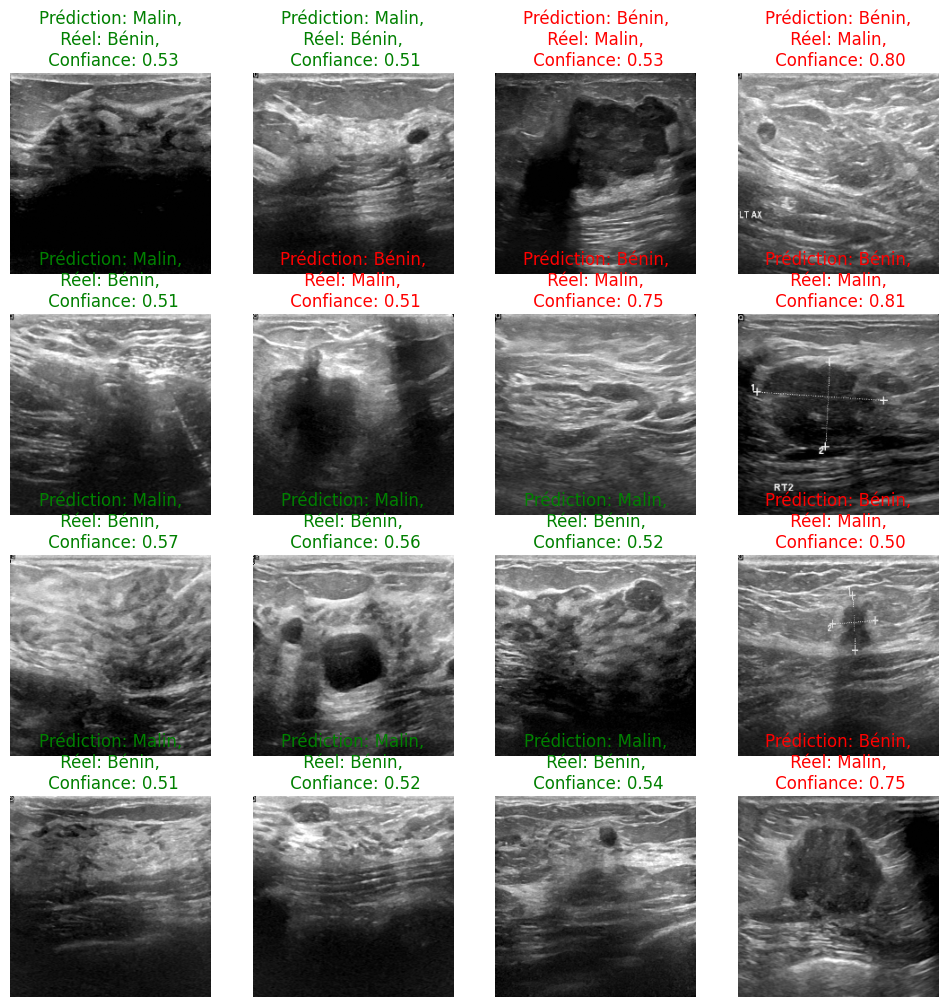

In [ ]:
# ### 5. Find examples where the model made mistakes and try to explain why.

# **What?** Identify cases of errors manually and look for explanations (image characteristics, dataset bias, etc.).
# **Why?** Understand the model's limitations and have concrete improvement suggestions.
# **How?** Filter the predictions to keep only the errors, then display the corresponding images.
print("\nExercise 5: Find examples where the model made mistakes and explain")

# Reuse the predictions and true labels from the previous exercise.

predicted_classes = (predictions_list > 0.5).astype(int)  # Convert probabilities to classes (0 or 1)
incorrect_indices = np.where(predicted_classes != true_labels_list)[0]  # Indices where the model made mistakes

# Display some examples of errors
plt.figure(figsize=(12, 12))
num_errors_to_show = min(16, len(incorrect_indices))  # To avoid displaying more than available

for i in range(num_errors_to_show):
    index = incorrect_indices[i]
    image = val_ds.unbatch().skip(index).take(1)  # Get the image that led to the error in the dataset

    for img, label in image:  # There is only one element in the dataset 'image'
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(img.numpy(), cmap='gray')  # Display the image

        predicted_label = "Malignant" if predictions_list[index] > 0.5 else "Benign"
        true_label = "Malignant" if true_labels_list[index] == 1 else "Benign"
        confidence = predictions_list[index] if predicted_label == "Malignant" else 1 - predictions_list[index]

        title_color = "green" if true_label == "Benign" else "red"  # Green if correct, red otherwise
        plt.title(f"Prediction: {predicted_label},\n True: {true_label}, \n Confidence: {confidence:.2f}", color=title_color)
        plt.axis('off')

plt.show()

# Possible explanations (to be verified case by case):
#    - Very blurry or noisy image.
#    - Low contrast between the lesion and surrounding tissues.
#    - Small or unusually shaped lesion.
#    - Presence of artifacts in the image.
#    - Dataset bias (e.g., overrepresentation of certain types of lesions).


# Analysis Exercise:

There are two types of possible errors:

- False Positives (FP): The model predicts "Malignant" while the true label is "Benign".
- False Negatives (FN): The model predicts "Benign" while the true label is "Malignant".

1. Observe carefully: For each image, examine:

- Blur (is the image sharp?)
- Contrast (does the lesion stand out well from the surrounding tissues?)
- Brightness (is the image generally dark or bright?)
- Size and shape of the lesion (if visible)
- Possible presence of artifacts (elements that are not part of the normal anatomy)

2. Formulate hypotheses: For each error, try to answer the question: "Why did the model make a mistake on this image?"

- Write down the hypotheses.
- Use the knowledge gained in the previous exercises (on blur, contrast, etc.).

3. Group the errors: Try to identify recurring types of errors. For example:

- "The model struggles with small lesions."
- "The model often makes mistakes when the contrast is low."
- "There is a type of lesion (e.g., calcifications) that the model tends to misclassify."

4. Relate to metrics (optional)

- Reuse the code from exercise 4 to display, in addition to the image, the calculated values for contrast, blur, and brightness, which will allow students to validate some of their hypotheses.


# Going Further:
   - Increase the number of epochs (with caution, to avoid overfitting).
   - Try other CNN architectures (deeper, pre-trained...).
   - Use more advanced interpretability techniques (Grad-CAM, SHAP...).
   - Collect more data, especially examples that are problematic for the model.
   - Consult medical experts to validate the results and identify potential biases.